In [1]:
from matplotlib import pyplot as plt
import os
import pickle
import numpy as np

In [2]:
import pandas as pd

In [3]:
currdir=os.getcwd()

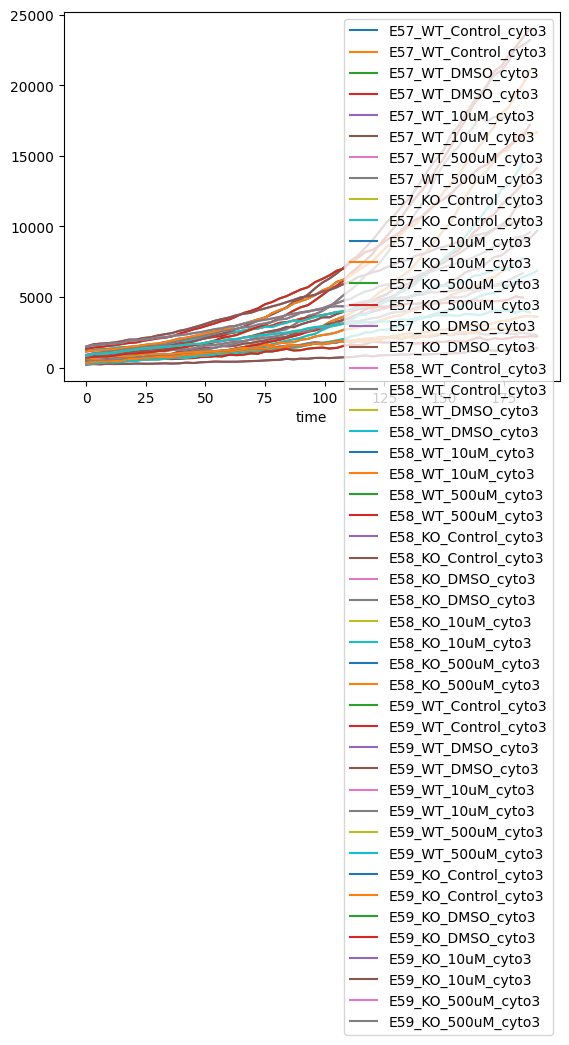

In [4]:
data = pd.read_csv("../data/brightfield/150h_replicates/growth_curves_57-58-59.csv",header=[0,1],index_col=0)
fig,ax = plt.subplots()
for e in data.columns.get_level_values(0):
    data[e].plot("time","counts",ax=ax,label=e)


In [9]:
data.head()

E57_WT_Control_cyto3        E57_WT_DMSO_cyto3        E57_WT_10uM_cyto3  \
                  time counts              time counts              time   
0                  0.0    372               0.0    427               0.0   
1                  3.0    391               3.0    449               3.0   
2                  6.0    423               6.0    461               6.0   
3                  9.0    449               9.0    494               9.0   
4                 12.0    474              12.0    525              12.0   

         E57_WT_500uM_cyto3        E57_KO_Control_cyto3         ...  \
  counts               time counts                 time counts  ...   
0    511                0.0    462                  0.0    406  ...   
1    533                3.0    508                  3.0    424  ...   
2    558                6.0    533                  6.0    448  ...   
3    603                9.0    548                  9.0    462  ...   
4    658               12.0    604                 12.0    475  ...   

  E59_WT_500uM_cyto3         E59_KO_Control_cyto3         E59_KO_DMSO_cyto3  \
                time  counts                 time  counts              time   
0                0.0   834.0                  0.0  1142.0               0.0   
1                3.0   970.0                  3.0  1217.0               3.0   
2                6.0   976.0                  6.0  1250.0               6.0   
3                9.0  1015.0                  9.0  1287.0               9.0   
4               12.0  1068.0                 12.0  1316.0              12.0   

          E59_KO_10uM_cyto3         E59_KO_500uM_cyto3          
   counts              time  counts               time  counts  
0  1335.0               0.0  1491.0                0.0  1464.0  
1  1422.0               3.0  1653.0                3.0  1601.0  
2  1465.0               6.0  1702.0                6.0  1617.0  
3  1541.0               9.0  1736.0                9.0  1684.0  
4  1585.0              12.0  1786.0               12.0  1717.0  

[5 rows x 48 columns]

In [10]:
data['E57_WT_Control_cyto3']['time']

0       0.0
1       3.0
2       6.0
3       9.0
4      12.0
      ...  
59    177.0
60    180.0
61    183.0
62    186.0
63    189.0
Name: time, Length: 64, dtype: float64

In [11]:
[colname for colname in data.columns if 'E57_WT' in colname[0]]

[('E57_WT_Control_cyto3', 'time'),
 ('E57_WT_Control_cyto3', 'counts'),
 ('E57_WT_DMSO_cyto3', 'time'),
 ('E57_WT_DMSO_cyto3', 'counts'),
 ('E57_WT_10uM_cyto3', 'time'),
 ('E57_WT_10uM_cyto3', 'counts'),
 ('E57_WT_500uM_cyto3', 'time'),
 ('E57_WT_500uM_cyto3', 'counts')]

In [12]:
[colname[0] for colname in data.columns if ('time' in colname[1] and 'E57_WT' in colname[0] and 'DMSO' in colname[0])]

['E57_WT_DMSO_cyto3']

In [9]:
# time [h] when TMZ was added:
TMZ_times=np.array([115/6., 106/6., 121/6.])

['E57_WT_DMSO_cyto3', 'E58_WT_DMSO_cyto3', 'E59_WT_DMSO_cyto3']


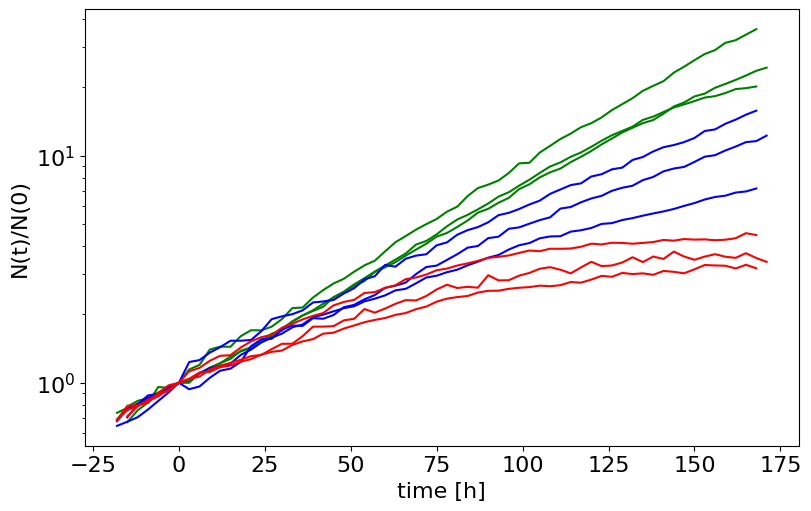

In [11]:
cols=[colname[0] for colname in data.columns if ('time' in colname[1] and 'WT' in colname[0] and 'DMSO' in colname[0])]
print(cols)
plt.rcParams['font.size'] = '16'
plt.rcParams["figure.figsize"] = (8,5)
plt.figure(constrained_layout=True)
for c,t0 in zip(cols,TMZ_times//3):
    plt.plot(np.array(data[c]['time']-data[c]['time'][t0]),np.array(data[c]['counts']/data[c]['counts'][t0]),c='g')

cols=[colname[0] for colname in data.columns if ('time' in colname[1] and 'WT' in colname[0] and '10uM' in colname[0])]
for c,t0 in zip(cols,TMZ_times//3):
    plt.plot(np.array(data[c]['time']-data[c]['time'][t0]),np.array(data[c]['counts']/data[c]['counts'][t0]),c='b')
    
  
cols=[colname[0] for colname in data.columns if ('time' in colname[1] and 'WT' in colname[0] and '500uM' in colname[0])]
for c,t0 in zip(cols,TMZ_times//3):
    plt.plot(np.array(data[c]['time']-data[c]['time'][t0]),np.array(data[c]['counts']/data[c]['counts'][t0]),c='r')

plt.xlabel("time [h]")
plt.ylabel("N(t)/N(0)")
plt.yscale('log')
plt.show()

['E57_WT_DMSO_cyto3', 'E58_WT_DMSO_cyto3', 'E59_WT_DMSO_cyto3']


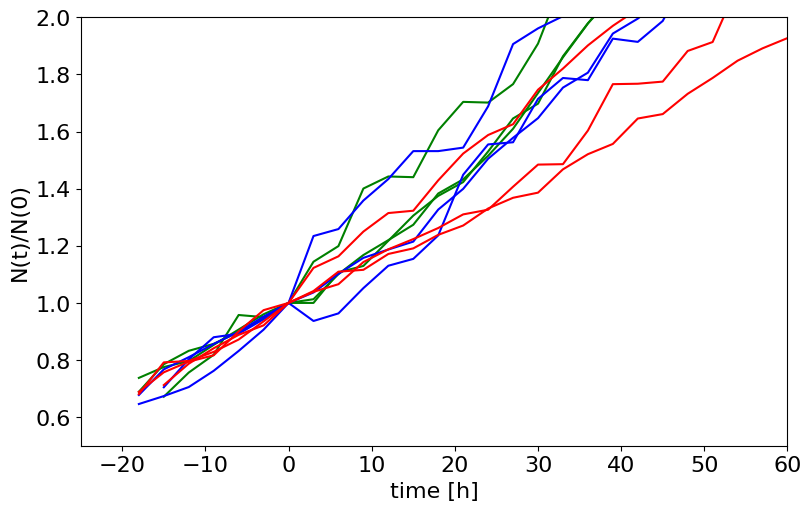

In [12]:
cols=[colname[0] for colname in data.columns if ('time' in colname[1] and 'WT' in colname[0] and 'DMSO' in colname[0])]
print(cols)
plt.rcParams['font.size'] = '16'
plt.rcParams["figure.figsize"] = (8,5)
plt.figure(constrained_layout=True)

for c,t0 in zip(cols,TMZ_times//3):
    plt.plot(np.array(data[c]['time']-data[c]['time'][t0]),np.array(data[c]['counts']/data[c]['counts'][t0]),c='g')


cols=[colname[0] for colname in data.columns if ('time' in colname[1] and 'WT' in colname[0] and '10uM' in colname[0])]
for c,t0 in zip(cols,TMZ_times//3):
    plt.plot(np.array(data[c]['time']-data[c]['time'][t0]),np.array(data[c]['counts']/data[c]['counts'][t0]),c='b')

   
cols=[colname[0] for colname in data.columns if ('time' in colname[1] and 'WT' in colname[0] and '500uM' in colname[0])]
for c,t0 in zip(cols,TMZ_times//3):
    plt.plot(np.array(data[c]['time']-data[c]['time'][t0]),np.array(data[c]['counts']/data[c]['counts'][t0]),c='r')

plt.xlabel("time [h]")
plt.ylabel("N(t)/N(0)")
plt.xlim(-25,60)
plt.ylim(0.5,2)
#plt.yscale('log')
plt.show()

## Fitting exponential growth to non-treated populations

['E57_WT_DMSO_cyto3', 'E58_WT_DMSO_cyto3', 'E59_WT_DMSO_cyto3']
growth rate =  0.01932430531313028
growth rate =  0.021535662140409556
growth rate =  0.01921258323386063


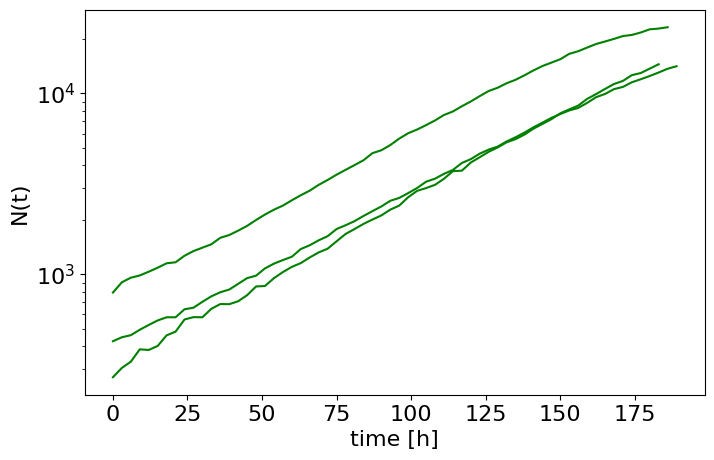

exp. growth rate [h^-1] =  0.02002418356246682  +/-  0.0006176201771376476
doubling time [h] =  34.710992624416484  +/-  1.031988824853485


In [21]:
cols=[colname[0] for colname in data.columns if ('time' in colname[1] and 'WT' in colname[0] and 'DMSO' in colname[0])]
print(cols)
plt.rcParams['font.size'] = '16'
plt.rcParams["figure.figsize"] = (8,5)
gr=[]
for c in cols:
    inds=~np.isnan(data[c]['counts'])
    #[d for d in data[c]['counts'] if np.isnan(d) is False]
    #print(inds)
    xx,yy=np.array(data[c]['time'][inds]),np.array(data[c]['counts'][inds])
    plt.plot(xx,yy,c='g')
    
    cc=np.polyfit(xx,np.log(yy),1)
    print("growth rate = ",cc[0])
    gr.append(cc[0])
    
plt.xlabel("time [h]")
plt.ylabel("N(t)")
plt.yscale('log')
plt.show()

print("exp. growth rate [h^-1] = ",np.mean(gr)," +/- ",np.std(gr)/np.sqrt(3))
dt=np.log(2)/gr
print("doubling time [h] = ",np.mean(dt)," +/- ",np.std(dt)/np.sqrt(3))

# Fig. 1B

In [27]:
data=np.genfromtxt("../data/brightfield/72h_single/data_exp33PD.csv",delimiter=',',names=True,skip_header=1)

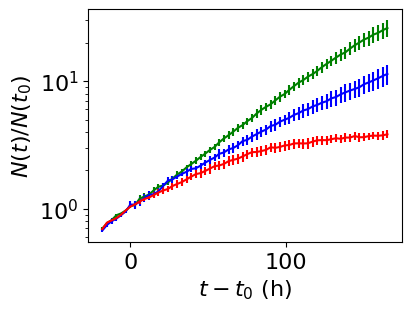

In [20]:
def plot_av(data,qx=1.,out_data=False,**kwargs):
    tmp=np.array(data)
    av=np.mean(tmp[:,:,1],axis=0)
    nsam=len(tmp[:,0,0])
    std=np.std(tmp[:,:,1],axis=0)/np.sqrt(nsam)
    if (out_data==True):
        return tmp[0,:,0]*qx,av,std
    else:
        plt.errorbar(tmp[0,:,0]*qx,av,std,**kwargs)

plt.rcParams["figure.figsize"] = (4,3)
plt.figure(constrained_layout=True)
for exp,color in zip(['DMSO','10uM','500uM'],['g','b','r']):
    cols=[colname[0] for colname in data.columns if ('time' in colname[1] and 'WT' in colname[0] and exp in colname[0])]
    tmp=[]
    
    for c,t in zip(cols,TMZ_times):
        t0=int(t//3)
        xy=np.array(data[c])
        tmp.append([[t-xy[t0,0],c/xy[t0,1]] for t,c in xy])

    plot_av(tmp,c=color)
    
plt.yscale('log')
plt.xlabel('$t-t_0$ (h)')
plt.ylabel("$N(t)/N(t_0)$")
plt.savefig(currdir+'/plots/growth_curves.svg',dpi=300)
plt.show()
plt.show()

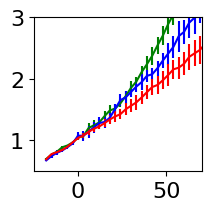

In [22]:
def plot_av(data,qx=1.,out_data=False,**kwargs):
    tmp=np.array(data)
    av=np.mean(tmp[:,:,1],axis=0)
    nsam=len(tmp[:,0,0])
    std=np.std(tmp[:,:,1],axis=0)/np.sqrt(nsam)
    if (out_data==True):
        return tmp[0,:,0]*qx,av,std
    else:
        plt.errorbar(tmp[0,:,0]*qx,av,std,**kwargs)

plt.rcParams["figure.figsize"] = (2,2)
plt.figure(constrained_layout=True)
for exp,color in zip(['DMSO','10uM','500uM'],['g','b','r']):
    cols=[colname[0] for colname in data.columns if ('time' in colname[1] and 'WT' in colname[0] and exp in colname[0])]
    tmp=[]
    
    for c,t in zip(cols,TMZ_times):
        t0=int(t//3)
        xy=np.array(data[c])
        tmp.append([[t-xy[t0,0],c/xy[t0,1]] for t,c in xy])

    plot_av(tmp,c=color)
    
plt.ylim(0.5,3)
plt.xlim(-25,70)
#plt.xlabel('$t-t_0$ (h)')
#plt.ylabel("$N(t)/N(t_0)$")
plt.savefig(currdir+'/plots/growth_curves_zoomed.svg',dpi=300)
plt.show()
plt.show()

# Fig. S1B

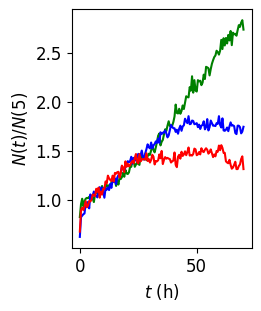

In [36]:
plt.rcParams['font.size'] = '12'
plt.rcParams["figure.figsize"] = (2.5,3)
plt.figure(constrained_layout=True)
cols=['02_DMSO_alltime','03_10um_alltime','04_500um_alltime']
t0=10
col=['g','b','r']
for i in range(0,3):
    plt.plot(data['02_DMSO_alltime_1'],data[cols[i]]/data[cols[i]][t0],c=col[i])
plt.xlabel('$t$ (h)')
plt.ylabel("$N(t)/N($"+str(t0//2)+")")
plt.savefig('plots/growth_curves_no_removal.png',dpi=300)
plt.show()

# Fig. S1C

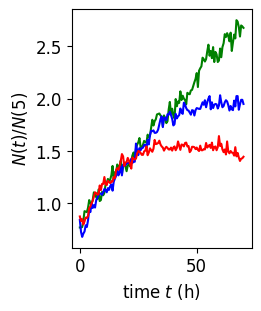

In [34]:
plt.rcParams['font.size'] = '12'
plt.rcParams["figure.figsize"] = (2.5,3)
plt.figure(constrained_layout=True)
cols=['10_DMSO_2h_removal','11_10um_2h_removal','12_500um_2h_removal']
t0=10
for i in range(0,3):
    plt.plot(data['02_DMSO_alltime_1'],data[cols[i]]/data[cols[i]][t0],c=col[i])
plt.xlabel('time $t$ (h)')
plt.ylabel("$N(t)/N($"+str(t0//2)+")")
plt.savefig(currdir+'/plots/growth_curves_2h_removal.png',dpi=300)
plt.show()


# Fig. S1D

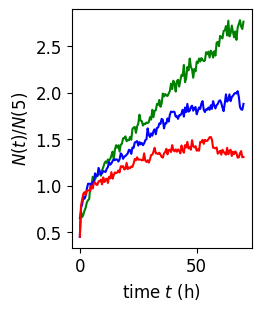

In [35]:
plt.rcParams['font.size'] = '12'
plt.rcParams["figure.figsize"] = (2.5,3)
plt.figure(constrained_layout=True)
cols=['06_DMSO30_min_removed','07_10um_30_min_removed','08_500um_30_min_removal']
t0=10
for i in range(0,3):
    plt.plot(data['02_DMSO_alltime_1'],data[cols[i]]/data[cols[i]][t0],c=col[i])
plt.xlabel('time $t$ (h)')
plt.ylabel("$N(t)/N($"+str(t0//2)+")")
plt.savefig(currdir+'/plots/growth_curves_30min_removal.png',dpi=300)
plt.show()


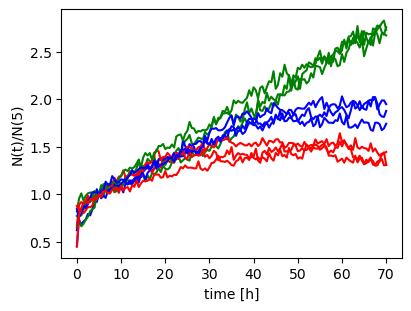

In [150]:
plt.rcParams['font.size'] = '10'
plt.rcParams["figure.figsize"] = (4,3)
plt.figure(constrained_layout=True)
cols=['02_DMSO_alltime','03_10um_alltime','04_500um_alltime','10_DMSO_2h_removal','11_10um_2h_removal','12_500um_2h_removal',
     '06_DMSO30_min_removed','07_10um_30_min_removed','08_500um_30_min_removal']
t0=10
color=['g','b','r']
for i in range(0,9):
    plt.plot(data['02_DMSO_alltime_1'],data[cols[i]]/data[cols[i]][t0],c=color[i%3])
plt.xlabel('time [h]')
plt.ylabel("N(t)/N("+str(t0//2)+")")
#plt.savefig(currdir+'\\growth_curves_2h_removal.png',dpi=300)
plt.show()

In [83]:
img=np.random.rand(4500,4500)

# KO ws WT

['E57_WT_DMSO_cyto3', 'E58_WT_DMSO_cyto3', 'E59_WT_DMSO_cyto3']


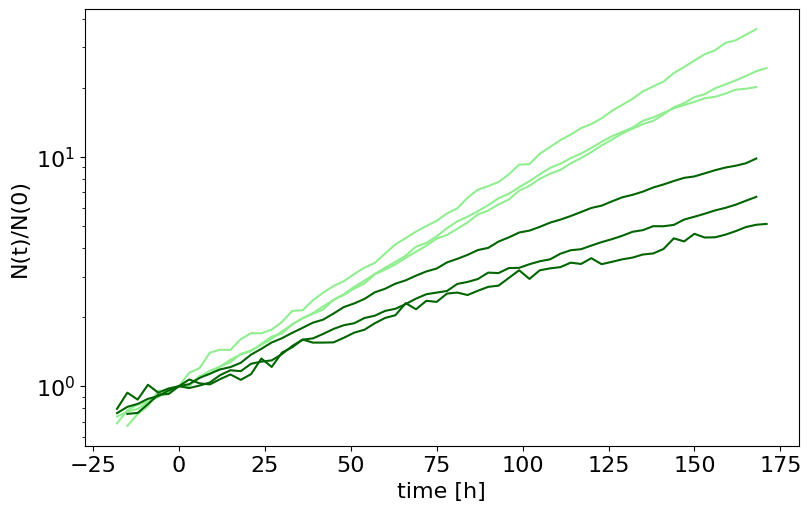

In [18]:
plt.rcParams['font.size'] = '16'
plt.rcParams["figure.figsize"] = (8,5)
plt.figure(constrained_layout=True)

cols=[colname[0] for colname in data.columns if ('time' in colname[1] and 'WT' in colname[0] and 'DMSO' in colname[0])]
print(cols)
for c,t0 in zip(cols,TMZ_times//3):
    plt.plot(np.array(data[c]['time']-data[c]['time'][t0]),np.array(data[c]['counts']/data[c]['counts'][t0]),c='lightgreen')

cols=[colname[0] for colname in data.columns if ('time' in colname[1] and 'KO' in colname[0] and 'DMSO' in colname[0])]
for c,t0 in zip(cols,TMZ_times//3):
    plt.plot(np.array(data[c]['time']-data[c]['time'][t0]),np.array(data[c]['counts']/data[c]['counts'][t0]),c='darkgreen')
    
  
#cols=[colname[0] for colname in data.columns if ('time' in colname[1] and 'WT' in colname[0] and '500uM' in colname[0])]
#for c,t0 in zip(cols,TMZ_times//3):
#    plt.plot(np.array(data[c]['time']-data[c]['time'][t0]),np.array(data[c]['counts']/data[c]['counts'][t0]),c='r')

plt.xlabel("time [h]")
plt.ylabel("N(t)/N(0)")
plt.yscale('log')
plt.show()

['E57_WT_10uM_cyto3', 'E58_WT_10uM_cyto3', 'E59_WT_10uM_cyto3']


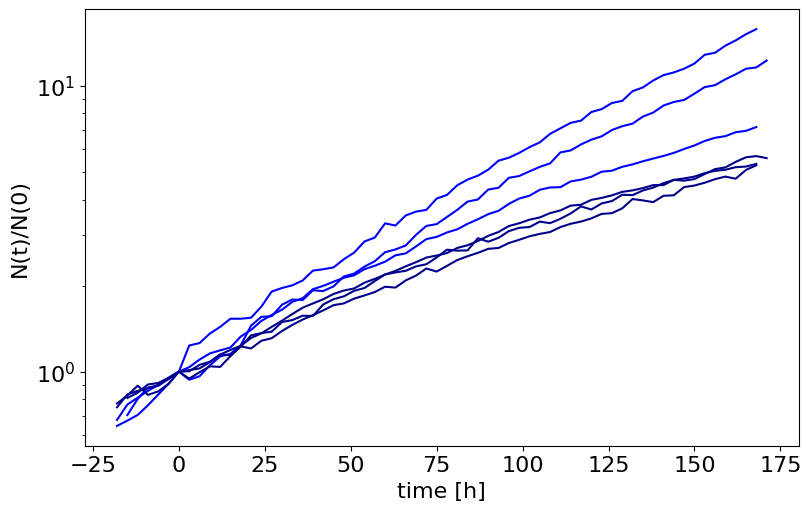

In [15]:
plt.rcParams['font.size'] = '16'
plt.rcParams["figure.figsize"] = (8,5)
plt.figure(constrained_layout=True)

cols=[colname[0] for colname in data.columns if ('time' in colname[1] and 'WT' in colname[0] and '10uM' in colname[0])]
print(cols)
for c,t0 in zip(cols,TMZ_times//3):
    plt.plot(np.array(data[c]['time']-data[c]['time'][t0]),np.array(data[c]['counts']/data[c]['counts'][t0]),c='b')

cols=[colname[0] for colname in data.columns if ('time' in colname[1] and 'KO' in colname[0] and '10uM' in colname[0])]
for c,t0 in zip(cols,TMZ_times//3):
    plt.plot(np.array(data[c]['time']-data[c]['time'][t0]),np.array(data[c]['counts']/data[c]['counts'][t0]),c='darkblue')
    
plt.xlabel("time [h]")
plt.ylabel("N(t)/N(0)")
plt.yscale('log')
plt.show()

['E57_WT_500uM_cyto3', 'E58_WT_500uM_cyto3', 'E59_WT_500uM_cyto3']


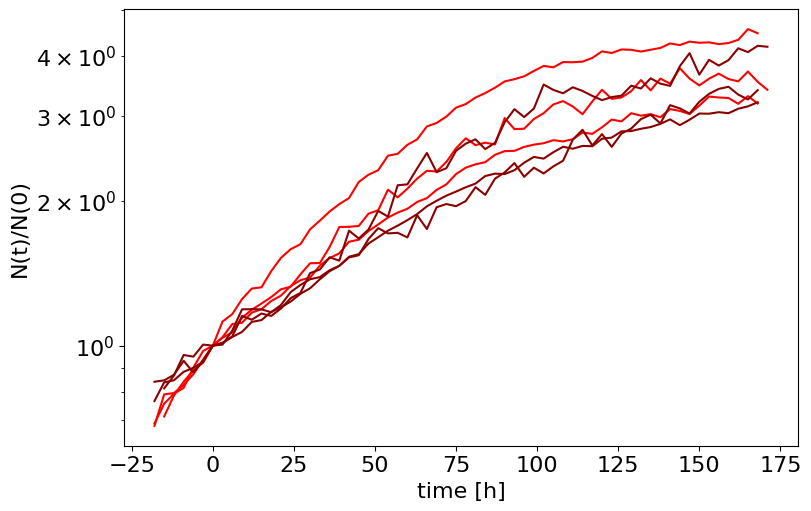

In [14]:
plt.rcParams['font.size'] = '16'
plt.rcParams["figure.figsize"] = (8,5)
plt.figure(constrained_layout=True)

cols=[colname[0] for colname in data.columns if ('time' in colname[1] and 'WT' in colname[0] and '500uM' in colname[0])]
print(cols)
for c,t0 in zip(cols,TMZ_times//3):
    plt.plot(np.array(data[c]['time']-data[c]['time'][t0]),np.array(data[c]['counts']/data[c]['counts'][t0]),c='r')

cols=[colname[0] for colname in data.columns if ('time' in colname[1] and 'KO' in colname[0] and '500uM' in colname[0])]
for c,t0 in zip(cols,TMZ_times//3):
    plt.plot(np.array(data[c]['time']-data[c]['time'][t0]),np.array(data[c]['counts']/data[c]['counts'][t0]),c='darkred')
    
plt.xlabel("time [h]")
plt.ylabel("N(t)/N(0)")
plt.yscale('log')
plt.show()

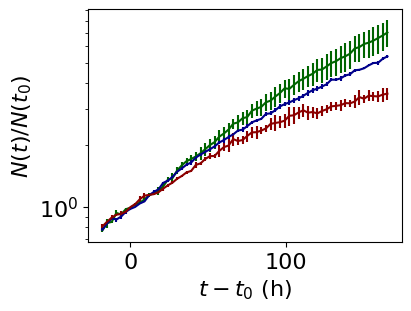

In [23]:
def plot_av(data,qx=1.,out_data=False,**kwargs):
    tmp=np.array(data)
    av=np.mean(tmp[:,:,1],axis=0)
    nsam=len(tmp[:,0,0])
    std=np.std(tmp[:,:,1],axis=0)/np.sqrt(nsam)
    if (out_data==True):
        return tmp[0,:,0]*qx,av,std
    else:
        plt.errorbar(tmp[0,:,0]*qx,av,std,**kwargs)

plt.rcParams["figure.figsize"] = (4,3)
plt.figure(constrained_layout=True)
#for exp,color in zip(['DMSO','10uM','500uM'],['green','b','r']):
#    cols=[colname[0] for colname in data.columns if ('time' in colname[1] and 'WT' in colname[0] and exp in colname[0])]
#    tmp=[]
    
#    for c,t in zip(cols,TMZ_times):
#        t0=int(t//3)
#        xy=np.array(data[c])
#        tmp.append([[t-xy[t0,0],c/xy[t0,1]] for t,c in xy])

#    plot_av(tmp,c=color)
    
for exp,color in zip(['DMSO','10uM','500uM'],['darkgreen','darkblue','darkred']):
    cols=[colname[0] for colname in data.columns if ('time' in colname[1] and 'KO' in colname[0] and exp in colname[0])]
    tmp=[]
    
    for c,t in zip(cols,TMZ_times):
        t0=int(t//3)
        xy=np.array(data[c])
        tmp.append([[t-xy[t0,0],c/xy[t0,1]] for t,c in xy])

    plot_av(tmp,c=color)
    
plt.yscale('log')
plt.xlabel('$t-t_0$ (h)')
plt.ylabel("$N(t)/N(t_0)$")
plt.savefig(currdir+'/plots/growth_curves_WT_and_KO.svg',dpi=300)
plt.show()
plt.show()